# Dfsu 3D

Layered dfsu files comes in several different shapes:

* 3D
* 2D Vertical slice (transect)
* 1D Vertical profile

Two layer systems exist:

* sigma (terrain and surface following coordinates)
* sigma-z (sigma layers at the top and fixed z-layers at the bottom)

In sigma-layered files, all columns has the same number of layers. In sigma-z files, the number of z-layers can be different for different columns.  

Layered dfsu files have a "hidden" first dynamic item called "zn" with the (dynamic) z-positions of the nodes. 

Read the [MIKE IO dfsu documentation](https://dhi.github.io/mikeio/user-guide/dfsu.html) for more info.

In [2]:
import mikeio

## 3D Sigma-z

In [3]:
dfs = mikeio.open("data/oresund_sigma_z.dfsu")
dfs

<mikeio.Dfsu3D>number of nodes: 12042
number of elements: 17118
projection: UTM-33
number of sigma layers: 4
max number of z layers: 5
items:
  0:  Temperature <Temperature> (degree Celsius)
  1:  Salinity <Salinity> (PSU)
time: 1997-09-15 21:00:00 - 1997-09-16 03:00:00 (3 records)

Apart from the normal dfsu properties, layered dfsu geometries have these properties: 

In [4]:
g = dfs.geometry

print(f"Maximum number of layers: {g.n_layers}")
print(f"Number of sigma layers: {g.n_sigma_layers}")
print(f"Maximum number of z-layers: {g.n_z_layers}")
print(f"The layer number for each 3d element: {g.layer_ids}")
print(f"List of 3d element ids of surface layer: {g.top_elements}")
print(f"List of 3d element ids of bottom layer: {g.bottom_elements}")
print(f"List of number of layers for each column: {g.n_layers_per_column}")
print(f"The 2d-to-3d element connectivity table for a 3d object: {g.e2_e3_table[:3]} ...")
print(f"The associated 2d element id for each 3d element: {g.elem2d_ids}")

Maximum number of layers: 9
Number of sigma layers: 4
Maximum number of z-layers: 5
The layer number for each 3d element: [4 5 6 ... 6 7 8]
List of 3d element ids of surface layer: [    4     8    12 ... 17106 17111 17117]
List of 3d element ids of bottom layer: [    0     5     9 ... 17102 17107 17112]
List of number of layers for each column: [5 4 4 ... 5 5 6]
The 2d-to-3d element connectivity table for a 3d object: [array([0, 1, 2, 3, 4]) array([5, 6, 7, 8]) array([ 9, 10, 11, 12])] ...
The associated 2d element id for each 3d element: [   0    0    0 ... 3699 3699 3699]


The associated 2D geometry for a 3D file can be outputted in this way:

In [5]:
geom2d = g.geometry2d
geom2d

Flexible Mesh Geometry: Dfsu2D
number of nodes: 2090
number of elements: 3700
projection: UTM-33

In [6]:
geom2d.n_elements

3700

### Layers in a 3D file

In [13]:
print("Number of elements per layer (5 z-layers, 4 sigma layers):")
for j in range(g.n_layers):
    dsl = dfs.read(layers=j)
    print(f"Layer {j}: {dsl.n_elements}")

Number of elements per layer (5 z-layers, 4 sigma layers):
Layer 0: 10
Layer 1: 86
Layer 2: 187
Layer 3: 528
Layer 4: 1507
Layer 5: 3700
Layer 6: 3700
Layer 7: 3700
Layer 8: 3700


The bottom layer is a list of the elements with the lowest id for each column
For sigma-z files it is NOT the same as layer 1.

In [ ]:
dfs.read(layers="bottom")

<mikeio.Dataset>
dims: (time:3, element:3700)
time: 1997-09-15 21:00:00 - 1997-09-16 03:00:00 (3 records)
geometry: Dfsu2D (3700 elements, 2090 nodes)
items:
  0:  Temperature <Temperature> (degree Celsius)
  1:  Salinity <Salinity> (PSU)

### Surface layer of 3D file

In [17]:
ds = dfs.read(layers="top")
ds

<mikeio.Dataset>
dims: (time:3, element:3700)
time: 1997-09-15 21:00:00 - 1997-09-16 03:00:00 (3 records)
geometry: Dfsu2D (3700 elements, 2090 nodes)
items:
  0:  Temperature <Temperature> (degree Celsius)
  1:  Salinity <Salinity> (PSU)

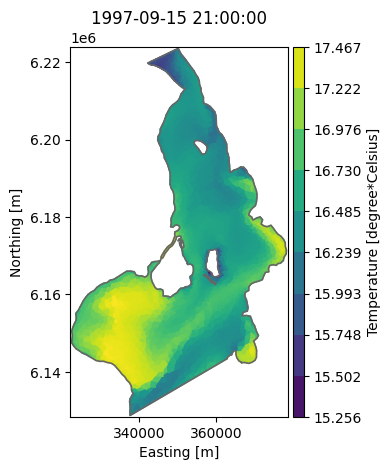

In [18]:
ds["Temperature"].plot();

In [19]:
max_t = ds['Temperature'].values.max()
print(f'Maximum temperature in top layer: {max_t:.1f}C')

Maximum temperature in top layer: 17.5C


### Find position of max temperature and plot

Use numpy argmax() method to find the element with the largest value.

In [20]:
max_elem_id = ds['Temperature'].isel(time=0).values.argmax()
top_element_coordinates = dfs.geometry.element_coordinates[dfs.geometry.top_elements]
max_x, max_y = top_element_coordinates[max_elem_id][:2]
max_x, max_y

(np.float64(333934.08510239207), np.float64(6158101.508170851))

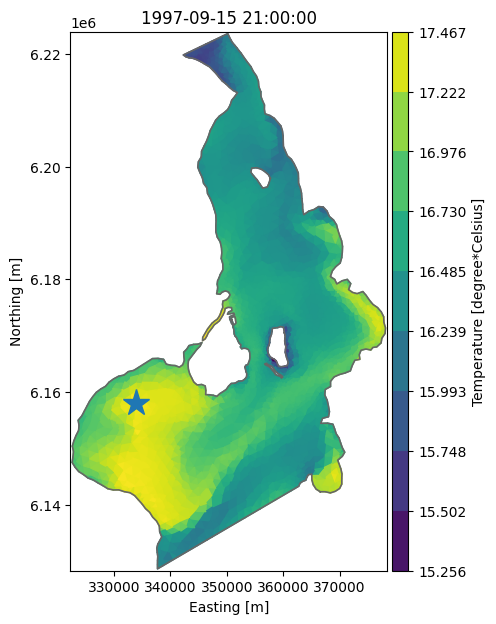

In [21]:
ax = ds['Temperature'].plot(figsize=(6,7))
ax.plot(max_x, max_y, marker='*', markersize=20);

# Read 1D profile from 3D file

Find water column which has highest temperature and plot profile for all 3 time steps using dynamic z information. 

In [23]:
dsp = dfs.read(x=max_x, y=max_y) # select vertical column from dfsu-3d 

In [25]:
dsp['Temperature'].shape   # 3 timesteps and 4 layers (no z-layers at this position)

(3, 4)

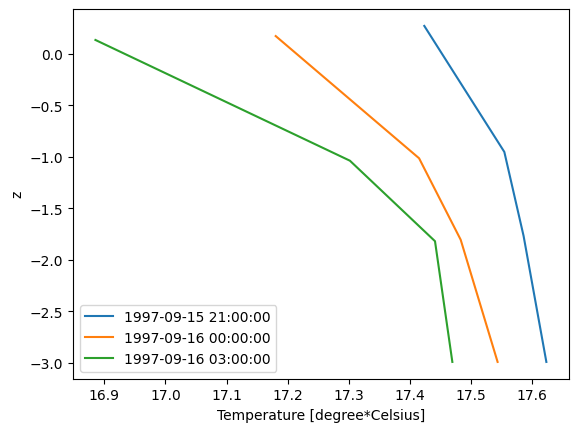

In [26]:
dsp['Temperature'].plot();

## Read vertical slice

In [27]:
dfs = mikeio.open("data/oresund_vertical_slice.dfsu")
dfs

<mikeio.Dfsu2DV>number of nodes: 550
number of elements: 441
projection: UTM-33
number of sigma layers: 4
max number of z layers: 5
items:
  0:  Temperature <Temperature> (degree Celsius)
  1:  Salinity <Salinity> (PSU)
time: 1997-09-15 21:00:00 - 1997-09-16 03:00:00 (3 records)

In [28]:
g = dfs.geometry
print(g.bottom_elements[:9])
print(g.n_layers_per_column[:9])
print(g.top_elements[:9])

[ 0  5 10 15 20 24 28 32 36]
[5 5 5 5 4 4 4 4 4]
[ 4  9 14 19 23 27 31 35 39]


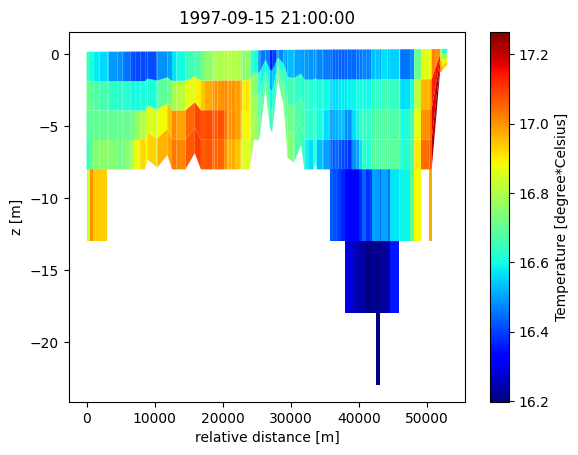

In [30]:
da = dfs.read(items="Temperature")[0]
da.plot();